In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt 
import os

In [2]:
pip install matplotlib


  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 17.8 MB/s eta 0:00:00
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
print('current directory',os.getcwd())

current directory c:\Users\Shushmitha\OneDrive\Desktop\AICW\plant\archive


In [5]:
current_directory= os.getcwd()
test_path=os.path.join(current_directory, "data","Testing")
train_path=os.path.join(current_directory,"data","Training")
valid_path=os.path.join(current_directory,"data","Validation")

In [6]:
test_path

'c:\\Users\\Shushmitha\\OneDrive\\Desktop\\AICW\\plant\\archive\\data\\Testing'

In [10]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    interpolation="bilinear",

)

Found 3251 files belonging to 3 classes.


In [11]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    interpolation="bilinear",

)

Found 3251 files belonging to 3 classes.


In [12]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3,activation='softmax'))

c:\Users\Shushmitha\OneDrive\Desktop\AICW\plant\archive\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy']
)

In [16]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
training_history=cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


c:\Users\Shushmitha\OneDrive\Desktop\AICW\plant\archive\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


102/102 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.5238 - loss: 0.9894 - val_accuracy: 0.6346 - val_loss: 0.8494
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.6583 - loss: 0.7706 - val_accuracy: 0.8170 - val_loss: 0.5740
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.7998 - loss: 0.5116 - val_accuracy: 0.8188 - val_loss: 0.4688
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8640 - loss: 0.3574 - val_accuracy: 0.8997 - val_loss: 0.2730
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8982 - loss: 0.2779 - val_accuracy: 0.9262 - val_loss: 0.2068
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9216 - loss: 0.2203 - val_accuracy: 0.9200 - val_loss: 0.2112
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.9326 - loss: 0.1913 - val_accuracy: 0.9462 - val_loss: 0.1587
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9419 - loss: 0.1699 - val_accuracy: 0.959

In [18]:
train_loss,train_acc=cnn.evaluate(validation_set)
print("validation accuracy",train_acc)

102/102 ━━━━━━━━━━━━━━━━━━━━ 31s 303ms/step - accuracy: 0.9769 - loss: 0.0667
validation accuracy 0.9769302010536194


In [19]:
cnn.save('trained_plant_disease_model.keras')

In [20]:
training_history.history

{'accuracy': [0.5238388180732727,
  0.6582589745521545,
  0.7997539043426514,
  0.864041805267334,
  0.8981851935386658,
  0.9215626120567322,
  0.9326360821723938,
  0.941864013671875,
  0.9652414917945862,
  0.9643186926841736],
 'loss': [0.9894115328788757,
  0.7706143260002136,
  0.5115965008735657,
  0.3573684096336365,
  0.27789685130119324,
  0.22030997276306152,
  0.19127732515335083,
  0.16985894739627838,
  0.11023534834384918,
  0.09910165518522263],
 'val_accuracy': [0.6345739960670471,
  0.8169794082641602,
  0.8188250064849854,
  0.8997231721878052,
  0.9261765480041504,
  0.9200246334075928,
  0.9461703896522522,
  0.9590895175933838,
  0.9800061583518982,
  0.9769302010536194],
 'val_loss': [0.8494008183479309,
  0.5739874243736267,
  0.4688177704811096,
  0.2729717195034027,
  0.20680181682109833,
  0.21115484833717346,
  0.15872794389724731,
  0.1211695447564125,
  0.06248760595917702,
  0.06674478948116302]}

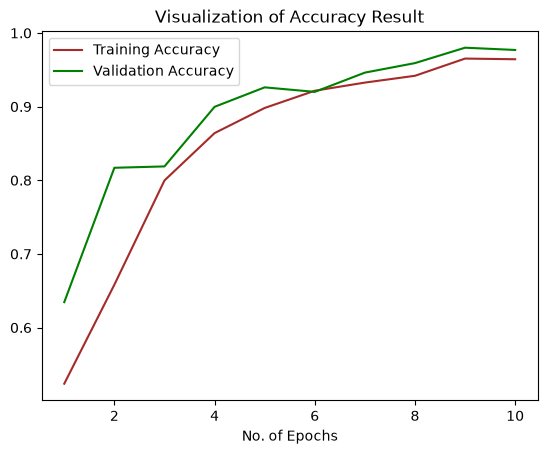

In [22]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='brown',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='green',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()